---
# PHASE 1: Load the data
---

In [45]:
import numpy as np

# Understand IDX file  

lets say for the image file: **train-images-idx3-ubyte** ,
- the header contains:
    - magic number
    - number of images
    - number of rows
    - number of columns

- for MNIST, these info are:
    - 2051 = 0x 00 00 08 03  = uint8 (data per pixel), 3D array
    - 60000
    - 28
    - 28

- the file is 3D because 1 image is 2D, and there are multiple images stacked




In [46]:
def load_images(path):
    with open(path, "rb") as f:    # rb = read binary 
        
        header = np.frombuffer(f.read(16), dtype=">u4")
        
        # np.frombuffer(buffer, datatype)
        # f.read(16) returns a memory chunk, each piece is a byte. so there are 16 byte....
        # dtype shows how many byte each chunk of data is, as we are reading byte by byte
        # read the first 16 byte, ">u4" = each data is 4 byte from left to right, unsigned
        # so 16 bytes = 4 unsigned integer
        # each of those integeer has 4 byte in them, ordered in Big Endian
        
        images = np.frombuffer( f.read(), dtype=np.uint8 )        
        
        # same shit, but now:
        # f.read() doesn't mention how many byte, so read until over
        # btw, it started after the first 16 byte 
        # dtype is now not mentioning Endian. becaue uint8 is just a sigle byte
        # endian is the order among multiple bytes, in single byte, order oesnt matter
        # effectively  np.uint8 = "u1" 
        
        
    # so now header is an array, containing 4 integers
        # magic number  header[0]
        # number of images  header[1]
        # rows per image   header[2]
        # columns per row  header[3]
    

    images = images.reshape(header[1], header[2], header[3])
    # images was a raw 1D array, all flattened. [ [ [1byte]x28  ]x28  ]x60000
    # so reshape it into 3D array

    return images

In [47]:
def load_images(path):
    
    headerSize=16  #in byte, 16 byte = 4 unsigned integer
        
    with open(path, "rb") as f:    # rb = read binary 
            
        header = np.frombuffer(f.read(headerSize), dtype=">u4")  
        #np.frombuffer turns a buffer of bytes, into an array of given datatype
        # np.frombuffer(buffer, datatype)
        # f.read(16) returns a memory chunk, each piece is a byte. so there are 16 byte....
        # dtype shows how many byte each chunk of data is, as we are reading byte by byte
        # read the first 16 byte, ">u4" = each data is 4 byte from left to right, unsigned
        # so 16 bytes = 4 unsigned integer
        # each of those integeer has 4 byte in them, ordered in Big Endian
        
        images = np.frombuffer( f.read(), dtype=np.uint8 )        
        
        # same shit, but now:
        # f.read() doesn't mention how many byte, so read until over
        # btw, it started after the first 16 byte 
        # dtype is now not mentioning Endian. becaue uint8 is just a sigle byte
        # endian is the order among multiple bytes, in single byte, order oesnt matter
        # effectively  np.uint8 = "u1" 
        
        
    # so now header is an array, containing 4 integers
        # magic number  header[0]
        # number of images  header[1]
        # rows per image   header[2]
        # columns per row  header[3]
    

    images = images.reshape(header[1], header[2], header[3])
    # images was a raw 1D array, all flattened. [ [ [1byte]x28  ]x28  ]x60000
    # so reshape it into 3D array

    return images

In [48]:
def load_labels(path):
    
    headerSize=8  
    
    with open(path, "rb") as f:
        
        f.read(headerSize)  #ignore header, no need

        
        labels = np.frombuffer( f.read(), dtype=np.uint8 )   
        
        #labels are also 1 d array, no need to reshape, 
    
    return labels


In [49]:
X_train = load_images("../../data/train-images-idx3-ubyte")
y_train = load_labels("../../data/train-labels-idx1-ubyte")

X_test = load_images("../../data/t10k-images-idx3-ubyte")
y_test = load_labels("../../data/t10k-labels-idx1-ubyte")

as explained before, X_train or X_test is 3D
for X_train these 3 Dimensions are:
- 6000 image
    - 28 rows per image
        - 28 columns per row

we can check is by printing the shape

In [50]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


so now, X_train[i] has a 2D array of an image and y_train[i] has the label of that image
same goes for X_test and y_test

lets visualize one of them, the one at index 0

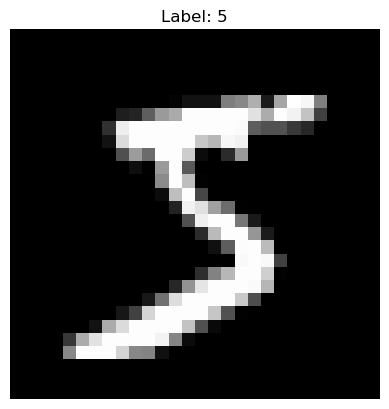

In [51]:
import matplotlib.pyplot as plt
def showImg(X,y):
    X = X.reshape(28,-1)
    plt.imshow(X, cmap="gray")
    plt.title(f"Label: {y}")
    plt.axis("off")
    plt.show()
    
showImg(X_train[0],y_train[0])


lets also check the frequency of each digit

In [52]:
freq = np.zeros((10,))

for digit in y_train:
    freq[digit]+=1

print(freq)

[5923. 6742. 5958. 6131. 5842. 5421. 5918. 6265. 5851. 5949.]


---
# PHASE 2: Validation
---

In [53]:
np.random.seed(42)   #so in each run, ranodomization stays same

# first of all, we don't shuffle them directly, then X and y may have different shuffle
# rather we create a random shuffle index, and reorder both X and y with that index

val_size = 1000   
# Because we take exactly 1,000 samples from every digit , total 10K validation sample

train_indices = []
val_indices = []  #val : validation

for digit in range(10):
    indices = np.where(y_train == digit)[0]
    np.random.shuffle(indices)

    val_indices.extend(indices[:val_size])
    train_indices.extend(indices[val_size:])

#convert from python list to np array
train_indices = np.array(train_indices)
val_indices = np.array(val_indices)

np.random.shuffle(train_indices)
np.random.shuffle(val_indices)

#index are ready, now apply them

X_val = X_train[val_indices]   # from the orginal training set, only keep those that were chosen for validation
y_val = y_train[val_indices]

X_train = X_train[train_indices]  #similarly, the rest for training
y_train = y_train[train_indices]

In [54]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)


In [55]:
print(np.bincount(y_train))
print(np.bincount(y_val))

# bin count means frequency count, for each unique item (here, for each digit)
# its the same code we did earlier in block 20

[4923 5742 4958 5131 4842 4421 4918 5265 4851 4949]
[1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


In [56]:
#scale down

X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0


# flaten from 28x28 to 784
X_train = X_train.reshape(X_train.shape[0], -1)   # -1 means numpy calculates the flatten dimention, basically multiply evething
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [57]:
# it was (m, 28, 28)  , now (m, 784)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(50000, 784)
(10000, 784)
(10000, 784)


---
# PHASE 3: FORWARD PASS
---

## Network Structure
```
Input
784 neurons
   ↓
Dense / Fully Connected
128 neurons
   ↓
ReLU
   ↓
Dense / Fully Connected
10 neurons
   ↓
Softmax
   ↓
10-class prediction
```

## parameters
```
W1: (784, 128)
b1: (128,)

W2: (128, 10)
b2: (10,)
```

## for one example
```
X              : (784,)
W1             : (784, 128)
b1             : (128,)
Z1 =X @ W1+ b1 : (128,)
A1 = ReLU(Z1)  : (128,)

W2             : (128, 10)
Z2=A1@W2+b2    : (10,)
A2=Softmax(Z2) : (10,)
```

## for a batch of 64
```
X              : (64, 784)
W1             : (784, 128)
b1             : (128,)
Z1 =X@W1+ b1   : (64,128)
A1 = ReLU(Z1)  : (64,128)

W2             : (128, 10)
Z2= A1@W2+b2   : (64,10)
A2=Softmax(Z2) : (64, 10)
```

## interesting numpy detail:
x @ W1+ b1 works even though  X@W1 is (64,128) and b1 is just (128,) the concept is called broadcasting, the same b1 vector is added to all 64 rows

* imagine X @ W1:

```
             128 values
         ┌─────────────────┐
example 1│ • • • • • • •   │
example 2│ • • • • • • •   │
example 3│ • • • • • • •   │ 64 rows
  ...    │      ...        │
example64│ • • • • • • •   │
         └─────────────────┘ 
```

* and,

```
b1 = [b₁, b₂, ..., b₁₂₈]
```


* NumPy matches the dimensions from the right:

```
Z1 : (64, 128)
b1 :      (128,)
```

* its matching with the second dimention, evething in all previous dimensions are just duplicated
* so one to one mapping with each 128 columns, and same thing duplicated over 64 rows

## code order
```
1. Initialize W1, b1, W2, b2
2. ReLU
3. Softmax
4. Forward pass
5. Cross-entropy loss
6. Backpropagation
7. Gradient descent update
8. Mini-batch training loop
9. Validation accuracy
10. Final test evaluation
```

In [58]:
NUM_FEATURES = 784
NUM_HIDDEN_1 = 128
NUM_OUTPUT = 10
NUM_BATCH = 64

LR = 0.05
EPOCHS = 30

In [59]:
# initialize parameters


def init_params():
 
    W1 = np.random.randn(NUM_FEATURES, NUM_HIDDEN_1) * np.sqrt(2 / NUM_FEATURES)
    b1 = np.zeros(NUM_HIDDEN_1)

    W2 = np.random.randn(NUM_HIDDEN_1, NUM_OUTPUT) * np.sqrt(2 / NUM_HIDDEN_1)
    b2 = np.zeros(NUM_OUTPUT)
    return W1, b1, W2, b2

small thing about random.randn
it picks value randomly from the normal distribution in z scale 
* Roughly 68.2% of the generated values fall between -1 and 1.
* Roughly 95.4% of the values fall between -2 and 2.
* Roughly 99.7% of the values fall between -3 and 3.

also the $ \sqrt{ \frac {2}{784} } $ is "He Initialization", here 784 is input layer size

and we are initializing bias at zero

In [60]:
def relu(z):
    return np.maximum(0, z)

# Z is (64,128)  so there are 64 image example, and 128 neuron's output, 
# we we do maximum, it gives element wize maximuum, 
# so for each 64 image, and for each value of neuron, if value < 0 , set to 0

# There is no "per image" decision involved here. 
# maximum doesn't need to know where one image ends and another begins. 
# It simply applies the same function to every element. 


def deriv_relu(Z):
    return Z>0

In [61]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# np.exp applies
# lets say z already holds all 10 values of 10 output neuron, so z is just (10,) = [z0, z1, z2...z9]
# so when we apply np.exp its applying on all, so now we have = [e^z0, e^z1, ..., e^z9]
# instead of np.exp(z)  we are doing np.exp(z - np.max(z) )
# this is just to scale the exponential down so its not enormously large

# then finally, we devide with np.sum(exp_z) , lets say sum = e^z0 + e^z1, ...+ e^z9
# so after division the result is , [e^z0/sum , e^z1/sum , ..., e^z9/sum ]


# small twist
# actully thats for one image example, but as we are working with batch, the true shape of z is not (10,)
# the shape of z is (64, 10)  here 64 is batch size
# so thats why we are doing axis=1
# lets say for np.sum now, we have a sum per image, axis=0 is the imaage, and each image has 10 output neuron value, 
# so axis = 1 indicates the 10 output neuron vaulue per image
# so we are doing sum of 10 numbers, image by image, 
# if we didnt use axis=1, we would've done sum of all image together, not independently only on axis=1
# also keepdims=True keeps the shape intact


$$
\text {softmax}(z_i​)=\frac {e^{z_i}}{​\sum e^{z_j} }
$$

In [62]:
def forward_prop(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

def predict(X,W1,b1,W2,b2):
    _,_,_,A = forward_prop(X,W1,b1,W2,b2)
    
    return np.argmax(A,axis=1)

---
# PHASE 4: BACK PROPAGATION
--- 

## Y is one hotted
* so for Y=3 it becomes Y = [0,0,0,1,0,0,0,0,0,0]

## for one image i :
the loss function (CCE= Categorical Cross-Entropy ) is defined as:

$$
L_i = - \sum_{j=1}^{10}{Y_{i,j}log(A2_{i,j})}
$$

- as Y is one hotted, this collapses to a single term where $Y_j = 1$

- so for j = 3 for example we are left the activation of the neuron corresponds to 3 

$$
L_i = - log(A2_{3})
$$

for the whole batch, simply take the mean:
$$
L = \frac{1}{\text{batchSize}}\sum_{i=0}^{\text{batchSize}-1}{L_i}
$$


## find dL/dZ2

for this loss function L is a function of A2 and A2 = softmax(Z2): 

$$
\frac {\partial L}{\partial Z2} = \frac{A2 - Y}{batchSize} 
$$

the partial drivative looks same 
check the full derivation somewhere, I am not feeling like writing the whole thing here.


In [63]:
def one_hot(Y):
    one_hot_y = np.zeros((Y.size, 10))
    one_hot_y[np.arange(Y.size),Y] = 1
    
    return one_hot_y

In [64]:
def back_prop(Y, A2,W2, A1, Z1, X):
    
    # dL/dW2 = dL/dZ2 * dZ2/dW2 = dL/dZ2 * A1
    # remember, dL/dW2 's shape will be same as W2's shape,
    # thats why during matrix multiplication we need be careful about when to transpose
    
    BATCH_SIZE = X.shape[0]

    dZ2= (A2-Y)/BATCH_SIZE
    dW2 = A1.T@dZ2     # dZ2 (m,10) A1(m,128)   m is the batch_size, we want (128,m)@(m,10)=(128,10)
    db2 = np.sum(dZ2, axis=0)  
    # axis = 0 because dZ2 (m,10) , for each column, meaning for each of the 10 neuron, sum bias of all image
    
    dZ1=(dZ2@W2.T)*deriv_relu(Z1)
    dW1 = X.T@dZ1 
    db1 = np.sum(dZ1, axis=0)
    
    return dW1, db1, dW2, db2    

In [65]:
def save_weights(W1, b1, W2, b2, filename="weights.npz"):
    np.savez(
        filename,
        W1=W1,
        b1=b1,
        W2=W2,
        b2=b2
    )


def load_weights(filename="weights.npz"):
    data = np.load(filename)

    W1 = data["W1"]
    b1 = data["b1"]
    W2 = data["W2"]
    b2 = data["b2"]

    return W1, b1, W2, b2

In [66]:
def train_and_save_weights():
    W1, b1, W2, b2 = init_params()
    
    for epoch in range(EPOCHS):
        total_loss = 0
        correct = 0
        total = 0
        
        for start in range(0, X_train.shape[0], NUM_BATCH):
            end = min(start + NUM_BATCH, X_train.shape[0])
            
            X_batch = X_train[start:end]
            y_batch = y_train[start:end]
            
            y_batch = one_hot(y_batch)
            
            Z1, A1, Z2, A2 = forward_prop(
                X_batch, W1, b1, W2, b2
            )
            
            dW1, db1, dW2, db2 = back_prop(
                y_batch, A2, W2, A1, Z1, X_batch
            )
            
            # UPDATE PARAMETERS
            W1 -= LR * dW1
            b1 -= LR * db1
            W2 -= LR * dW2
            b2 -= LR * db2
            
            # loss
            loss = -np.mean(
                np.sum(y_batch * np.log(A2 + 1e-8), axis=1)
            )
            
            total_loss += loss * len(X_batch)
            
            # accuracy
            predictions = np.argmax(A2, axis=1)  # argmax = fnd index of max 
            labels = np.argmax(y_batch, axis=1)  # reverse of one_hot_code
            
            correct += np.sum(predictions == labels)
            total += len(X_batch)
        
        avg_loss = total_loss / total
        accuracy = correct / total
        
        # VALIDATION
        _, _, _, A2_val = forward_prop(
            X_val, W1, b1, W2, b2
        )
        
        val_predictions = np.argmax(A2_val, axis=1)
        val_accuracy = np.mean(val_predictions == y_val)
        
        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Loss: {avg_loss:.4f} | "
            f"Train Acc: {accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )
    
    save_weights(W1, b1, W2, b2)

## note:
Keep the next call, commented out onces training is complete, no need to train each time

In [67]:
train_and_save_weights()

Epoch 1/30 | Loss: 0.4806 | Train Acc: 0.8719 | Val Acc: 0.9051
Epoch 2/30 | Loss: 0.2698 | Train Acc: 0.9240 | Val Acc: 0.9252
Epoch 3/30 | Loss: 0.2212 | Train Acc: 0.9379 | Val Acc: 0.9337
Epoch 4/30 | Loss: 0.1891 | Train Acc: 0.9465 | Val Acc: 0.9409
Epoch 5/30 | Loss: 0.1655 | Train Acc: 0.9530 | Val Acc: 0.9471
Epoch 6/30 | Loss: 0.1475 | Train Acc: 0.9583 | Val Acc: 0.9513
Epoch 7/30 | Loss: 0.1331 | Train Acc: 0.9624 | Val Acc: 0.9547
Epoch 8/30 | Loss: 0.1214 | Train Acc: 0.9657 | Val Acc: 0.9570
Epoch 9/30 | Loss: 0.1115 | Train Acc: 0.9690 | Val Acc: 0.9592
Epoch 10/30 | Loss: 0.1030 | Train Acc: 0.9714 | Val Acc: 0.9608
Epoch 11/30 | Loss: 0.0956 | Train Acc: 0.9735 | Val Acc: 0.9631
Epoch 12/30 | Loss: 0.0891 | Train Acc: 0.9756 | Val Acc: 0.9641
Epoch 13/30 | Loss: 0.0833 | Train Acc: 0.9772 | Val Acc: 0.9646
Epoch 14/30 | Loss: 0.0782 | Train Acc: 0.9784 | Val Acc: 0.9657
Epoch 15/30 | Loss: 0.0735 | Train Acc: 0.9795 | Val Acc: 0.9667
Epoch 16/30 | Loss: 0.0694 | Train

---
# PHASE 5: Use Model
---

Once the model is trained and the weights are saved, the weights can be loaded anytime and reused without rerunning the previous codes (without retraining),
(we need to at least learn the cell of forward() and predict())

In [68]:
W1, b1, W2, b2 = load_weights()

In [69]:
test_predictions = predict(
    X_test, W1, b1, W2, b2
)

test_accuracy = np.mean(test_predictions == y_test)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9754


In [70]:
query = X_test[0:5]

print(predict(query))
print(y_test[0:5])

TypeError: predict() missing 4 required positional arguments: 'W1', 'b1', 'W2', and 'b2'

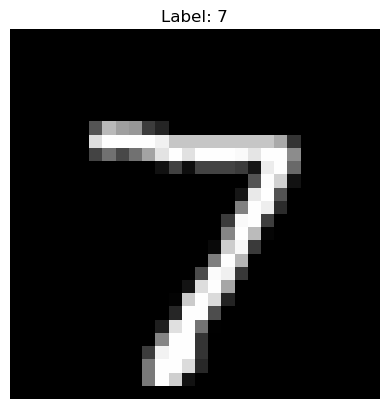

[7]


In [ ]:
showImg(X_test[0].reshape(28,28),y_test[0])
print(predict(X_test[0].reshape(1,-1)))